<a href="https://colab.research.google.com/github/RedEgnival/sem-4/blob/main/I069_ML_lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rusheel Sharma
# I069
# ML Lab 8 SVM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

# Task 1

Generate data

<ipython-input-3-21203752af34>:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


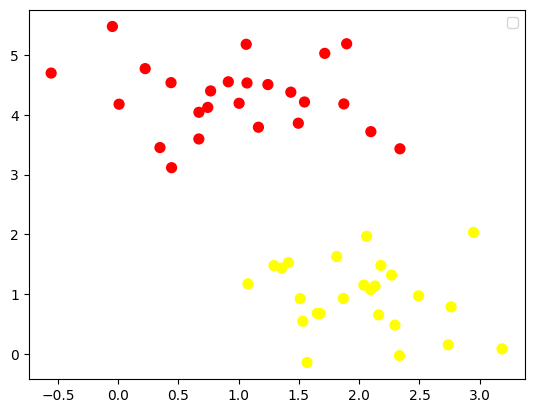

In [ ]:
x,y = make_blobs(n_samples=50,centers=2,random_state=0,cluster_std=0.60)
plt.scatter(x[:,0],x[:,1],c=y,s=50,cmap='autumn')
plt.legend()
plt.show()

Generate evenly spaced numbers b/w -1 and 3.5

In [ ]:
xfit = np.linspace(-1,3.5)
xfit


array([-1.        , -0.90816327, -0.81632653, -0.7244898 , -0.63265306,
       -0.54081633, -0.44897959, -0.35714286, -0.26530612, -0.17346939,
       -0.08163265,  0.01020408,  0.10204082,  0.19387755,  0.28571429,
        0.37755102,  0.46938776,  0.56122449,  0.65306122,  0.74489796,
        0.83673469,  0.92857143,  1.02040816,  1.1122449 ,  1.20408163,
        1.29591837,  1.3877551 ,  1.47959184,  1.57142857,  1.66326531,
        1.75510204,  1.84693878,  1.93877551,  2.03061224,  2.12244898,
        2.21428571,  2.30612245,  2.39795918,  2.48979592,  2.58163265,
        2.67346939,  2.76530612,  2.85714286,  2.94897959,  3.04081633,
        3.13265306,  3.2244898 ,  3.31632653,  3.40816327,  3.5       ])

Generate 3 lines

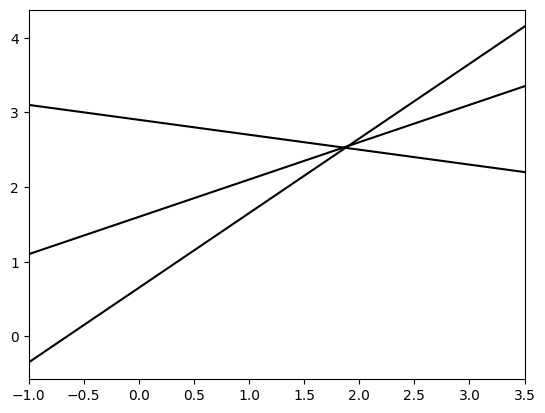

In [ ]:
for m,b  in [(1,0.65),(0.5,1.6),(-0.2,2.9)]:
  plt.plot(xfit,m*xfit+b,'k')
  plt.xlim(-1,3.5)


Plot these lines on the scatter plot

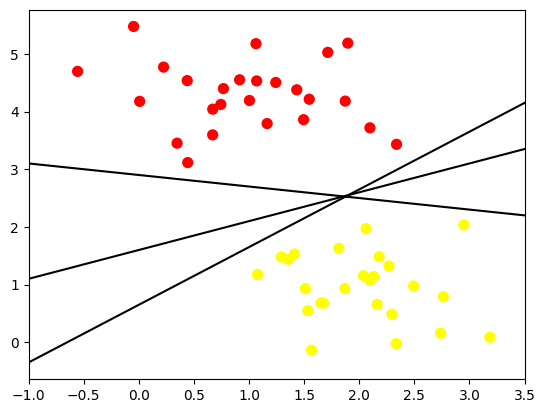

In [ ]:
plt.scatter(x[:,0],x[:,1],c=y,s=50,cmap='autumn')
for m,b in [(1,0.65),(0.5,1.6),(-0.2,2.9)]:
  plt.plot(xfit,m*xfit+b,'k')
  plt.xlim(-1,3.5)
plt.show()

Craete linear SVM model

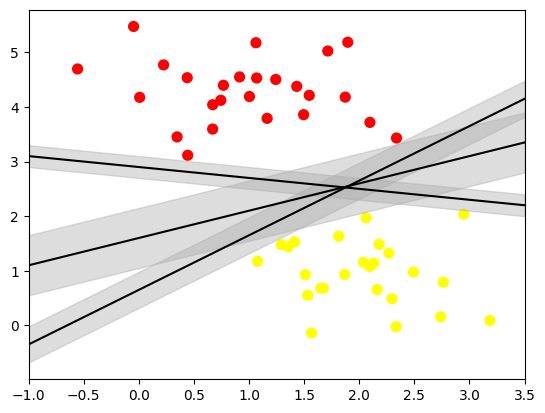

In [ ]:
model = SVC(kernel = "linear", C = 1e10)
model.fit(x,y)
SVC(C = 10000000000.0, kernel = "linear")

xfit = np.linspace(-1,3.5)
plt.scatter(x[:,0],x[:,1],c=y,s=50,cmap='autumn')
for m,b, d in [(1,0.65,0.33),(0.5,1.6,0.55),(-0.2,2.9,0.2)]:
  yfit = m * xfit + b
  plt.plot(xfit,yfit,'-k')
  plt.fill_between(xfit,yfit-d,yfit+d,edgecolor='none',color='#AAAAAA',alpha=0.4)
plt.xlim(-1,3.5)
plt.show()

Plot the decision boundary

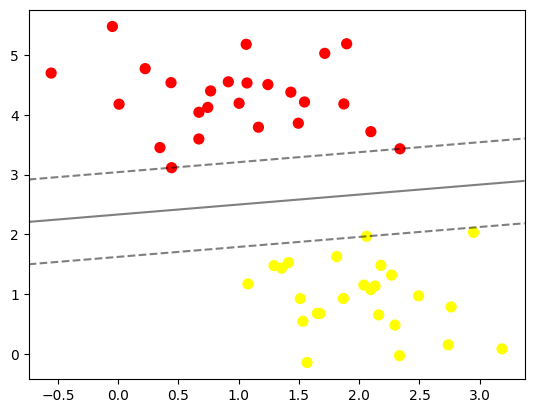

In [ ]:
def plot_svc_decision_function(model,ax=None,plot_support=True):

  ax = plt.gca()
  xlim = ax.get_xlim()
  ylim = ax.get_ylim()
  x = np.linspace(xlim[0],xlim[1],30)
  y = np.linspace(ylim[0],ylim[1],30)
  Y,X = np.meshgrid(y,x)
  xy = np.vstack([X.ravel(),Y.ravel()]).T
  P = model.decision_function(xy).reshape(X.shape)
  ax.contour(X,Y,P,colors='k',levels=[-1,0,1],alpha=0.5,linestyles=['--','-','--'])

  ax.scatter(model.support_vectors_[:,0],model.support_vectors_[:,1],s=300,linewidth=1,facecolors='none')
  ax.set_xlim(xlim)
  ax.set_ylim(ylim)

plt.scatter(x[:,0],x[:,1],c=y,s=50,cmap='autumn')
plot_svc_decision_function(model)
plt.show()

Determine support vectors

In [ ]:
model.support_vectors_

array([[0.44359863, 3.11530945],
       [2.33812285, 3.43116792],
       [2.06156753, 1.96918596]])

# Task 2

Generate dataset using make_circles

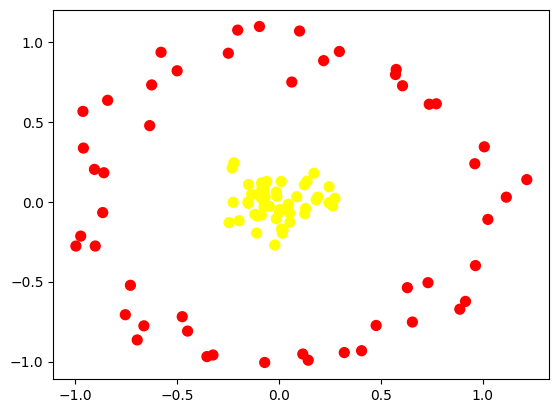

In [ ]:
from sklearn.datasets import make_circles
x,y = make_circles(100,factor=0.1,noise=0.1)
plt.scatter(x[:,0],x[:,1],c=y,s=50,cmap='autumn')

Craete linear SVM model

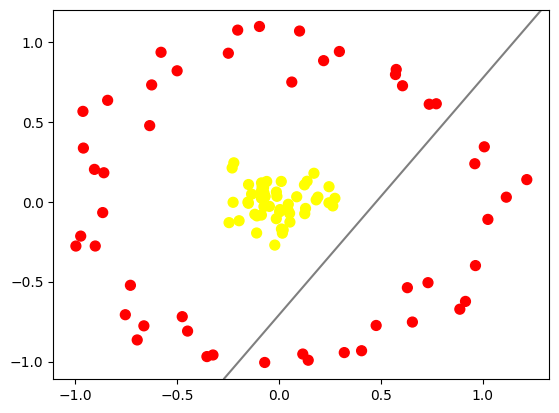

In [ ]:
clf = SVC(kernel='linear').fit(x,y)
plt.scatter(x[:,0],x[:,1],c=y,s=50,cmap='autumn')
plot_svc_decision_function(clf);

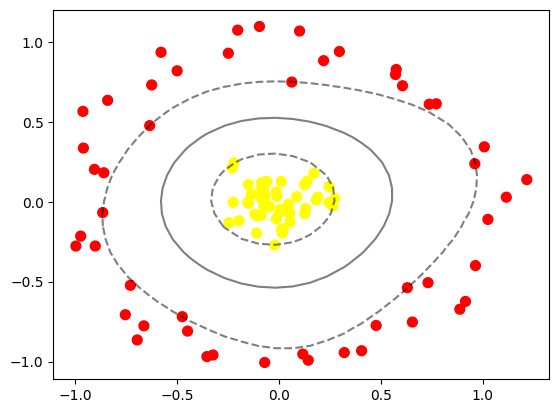

In [ ]:
from sklearn.svm import SVC
clf = SVC(kernel='rbf',C=10).fit(x,y)
SVC(C = 1000000.0)
plt.scatter(x[:,0],x[:,1],c=y,s=50,cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:,0], clf.support_vectors_[:,1],s = 300, lw = 1, facecolors = 'none');

# Task 3

import LFW dataset

In [ ]:
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.svm import SVC

In [ ]:
lfw = fetch_lfw_people(min_faces_per_person=70,resize=0.4)


In [ ]:
print("Number of samples", lfw.images.shape[0])
print("Number of features", lfw.images.shape[1]*lfw.images.shape[2])
print("Number of classes", len(lfw.target_names))

Number of samples 1288
Number of features 1850
Number of classes 7


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(lfw.data,lfw.target,test_size=0.25, random_state = 42)
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(x_train,y_train)
SVC(kernel = 'linear')
y_pred = svm_classifier.predict(x_test)
report = classification_report(y_test,y_pred, target_names=lfw.target_names)
print(report)


                   precision    recall  f1-score   support

     Ariel Sharon       0.56      0.77      0.65        13
     Colin Powell       0.81      0.87      0.84        60
  Donald Rumsfeld       0.61      0.70      0.66        27
    George W Bush       0.94      0.89      0.92       146
Gerhard Schroeder       0.73      0.88      0.80        25
      Hugo Chavez       0.89      0.53      0.67        15
       Tony Blair       0.88      0.78      0.82        36

         accuracy                           0.84       322
        macro avg       0.77      0.77      0.76       322
     weighted avg       0.85      0.84      0.84       322

